## ----------------------- KNN Algorithm using Sklearn -----------------------

#### Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

#### Importing Dataset

In [64]:
df  = pd.read_csv("https://raw.githubusercontent.com/sahdevsaini/Data-Set/main/Social_Network_Ads.csv")

In [5]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


#### Spliting the dataset in independent and dependent variables

In [13]:
X = df.iloc[:,2:4]        # independent feature 
y = df.iloc[:,-1]         # dependent feature 

#### Splitting the dataset into the Training set and Test set

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.20,random_state=42)

```python
Age   EstimatedSalary
19    19000
The difference in the Age & EstimatedSalary is very large
So, When we plot it on the graph it is not so easy to plot.
And KNN works on nearest Neighours. So accuracy of Algorithm 
will be afacted.
SO we will convert data in standard using scalar standard
```

#### Feature Scaling to bring the variable in a single scale

In [16]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

#### Finding the value of Neibhours(k)

In [26]:
k = int(np.sqrt(X_train.shape[0]))
k

17

#### Creating KNN Model As Classifier

In [27]:
from sklearn.neighbors import KNeighborsClassifier
knn_Classifier = KNeighborsClassifier(k)

#### Trained the model on Training data

In [28]:
knn_Classifier.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=17)

In [30]:
y_predicted = knn_Classifier.predict(X_test)

In [31]:
y_predicted

array([1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0])

#### Comapring y_test & y_Predicted 

In [34]:
Comp_Data = pd.DataFrame({"Actual Data" : y_test,
                         "Predicted data ": y_predicted})
Comp_Data

,Actual Data,Predicted data
209,0,1
280,1,1
33,0,0
210,1,1
93,0,0
...,...,...
246,0,0
227,1,1
369,1,1
176,0,0


#### Accuracy of the Model

In [36]:
from sklearn.metrics import accuracy_score
Accuracy = accuracy_score(y_test,y_predicted)
print("Accuracy of the Model is :- ",Accuracy*100)

Accuracy of the Model is :-  92.5


#### Confusion Matrix 

In [37]:
from sklearn.metrics import confusion_matrix
Matrix = confusion_matrix(y_test,y_predicted)
print(Matrix)

[[48  4]
 [ 2 26]]


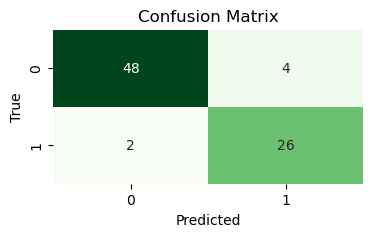

In [40]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_predicted)

# Plot confusion matrix
plt.figure(figsize=(4, 2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


#### F1 Score 

In [43]:
from sklearn.metrics import f1_score
score = f1_score(y_test,y_predicted)
print("The f1_score of Model:- ",score)

The f1_score of Model:-  0.896551724137931


In [78]:
# Effect of K on Training Error rate and Validation Error rate

error_train=[]
error_test=[]

for i in range(1,26):
    knn_Classifier=KNeighborsClassifier(n_neighbors=i)
    knn_Classifier.fit(X_train,y_train)
    x=confusion_matrix(y_train,knn_Classifier.predict(X_train))
    y=confusion_matrix(y_test,knn_Classifier.predict(X_test))
    error_train.append((x[0][1]+x[1][0])/x.sum())
    error_test.append((y[0][1]+y[1][0])/y.sum())

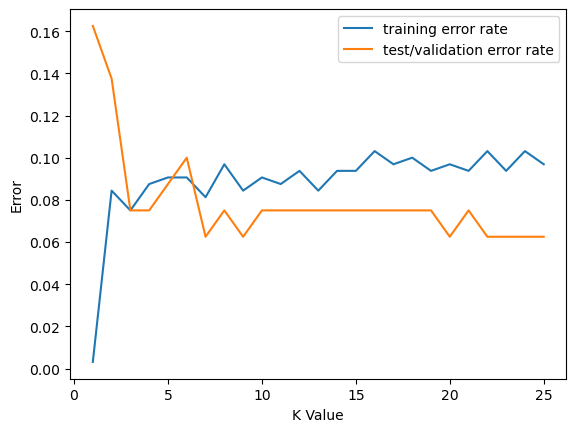

In [79]:
plt.plot(range(1,26),error_train,label='training error rate')
plt.plot(range(1,26),error_test,label='test/validation error rate')
plt.xlabel('K Value')
plt.ylabel('Error')
plt.legend()

In [130]:
from sklearn.neighbors import KNeighborsClassifier
knn_Classifier = KNeighborsClassifier(n_neighbors=7)

In [131]:
knn_Classifier.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=7)

In [132]:
y_predicted = knn_Classifier.predict(X_test)

In [133]:
from sklearn.metrics import accuracy_score
Accuracy = accuracy_score(y_test,y_predicted)
print(Accuracy*100)

93.75


#### Predict new Data

In [74]:
def predict_output():
    age=int(input("Enter the age"))
    salary=int(input("Enter the salary"))
    
    X_new=np.array([[age],[salary]]).reshape(1,2)
    X_new=sc.transform(X_new)
    
    if knn_Classifier.predict(X_new)[0]==0:
        return "Will not purchase"
    else:
        return "Will purchase"

In [75]:
predict_output()

Enter the age 30
Enter the salary 40000


/opt/conda/lib/python3.10/site-packages/sklearn/base.py:409: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'Will not purchase'